Loading data...
Train size: 180,264
Test size:  45,067
Classes:    10

Building model...
Training...
Evaluating...

Accuracy: 0.5124

Classification Report:
              precision    recall  f1-score   support

       blush       0.44      0.38      0.41      4568
     flushed       0.96      0.44      0.60      2067
        grin       0.83      0.32      0.47      2964
  heart_eyes       0.57      0.66      0.61      7919
     relaxed       0.94      0.25      0.40      2143
       smirk       0.68      0.35      0.47      3000
         sob       0.43      0.76      0.55      9989
       weary       0.45      0.40      0.43      5344
        wink       0.49      0.44      0.47      3679
         yum       0.65      0.39      0.49      3394

    accuracy                           0.51     45067
   macro avg       0.65      0.44      0.49     45067
weighted avg       0.57      0.51      0.50     45067


Sample Predictions:

TEXT:
i miss you so much
TOP PREDICTIONS:
  1. sob (😭) -> 0.80

<Figure size 1000x800 with 0 Axes>

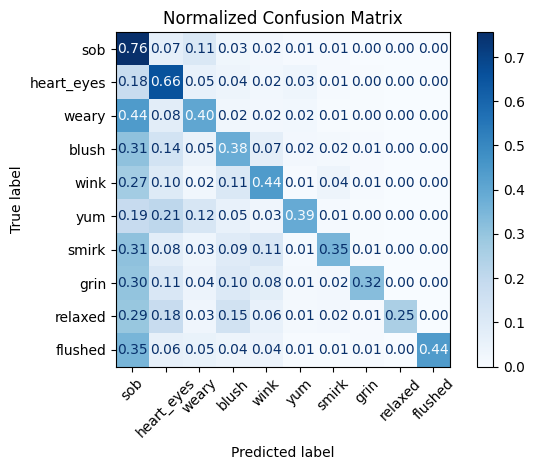



Per-Emoji Scores (of ten most frequent entries):



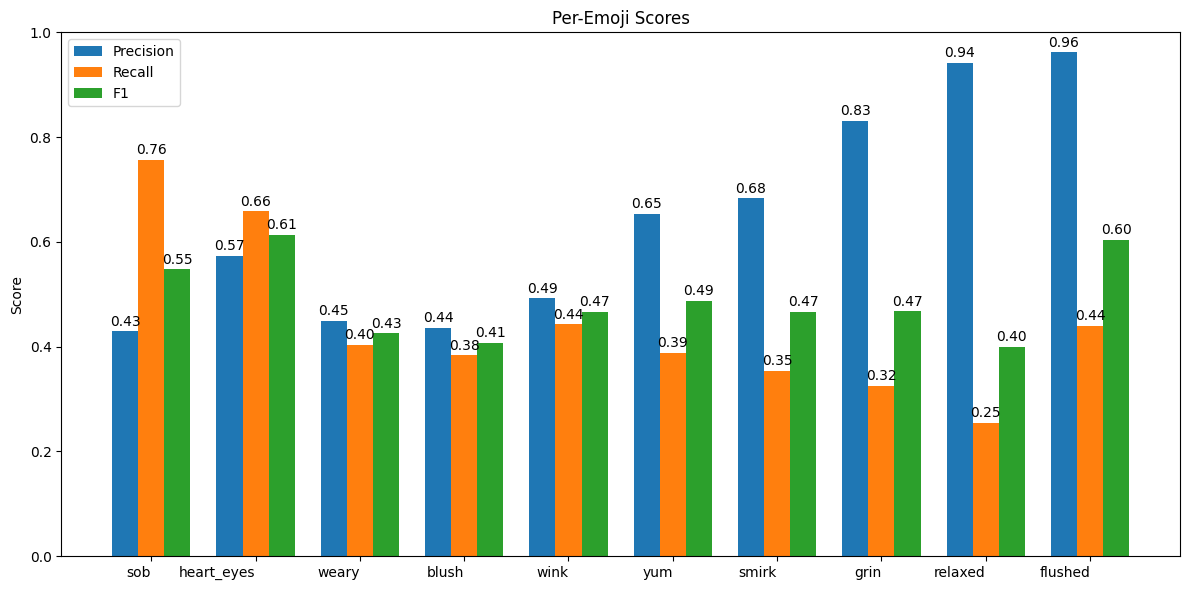

In [ ]:
import pickle
from pathlib import Path

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

# ---------- CONFIG ----------
DATA_PATH = "data_split.pkl"
TOP_K_PREDICTIONS = 3

# Mapped label names to actual emoji characters for display
EMOJI_MAP = {
    "sob": "😭",
    "heart_eyes": "😍",
    "weary": "😩",
    "blush": "😊",
    "unamused": "😒",
    "smirk": "😏",
    "ok_hand": "👌",
    "pensive": "😔",
    "grin": "😁",
    "notes": "🎶",
    "flushed": "😳",
    "100": "💯",
    "pray": "🙏",
    "relieved": "😌",
    "eyes": "👀",
    "joy": "😂",
    "broken_heart": "💔",
    "sparkles": "✨",
    "blue_heart": "💙",
    "two_hearts": "💕",
    "wink": "😉",
    "yum": "😋",
    "heart": "❤️",
    "relaxed": "😎"
}


def load_data(path):
    """
    Expects a pickle file containing:
        (X_train, X_test, y_train, y_test)
    """
    with open(path, "rb") as f:
        data = pickle.load(f)

    if not isinstance(data, tuple) or len(data) != 4:
        raise ValueError(
            "Expected pickle to contain a tuple of "
            "(X_train, X_test, y_train, y_test)."
        )

    X_train, X_test, y_train, y_test = data

    # Basic validation
    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train lengths do not match.")
    if len(X_test) != len(y_test):
        raise ValueError("X_test and y_test lengths do not match.")

    # Make sure everything is string-like
    X_train = ["" if x is None else str(x) for x in X_train]
    X_test = ["" if x is None else str(x) for x in X_test]
    y_train = ["" if y is None else str(y) for y in y_train]
    y_test = ["" if y is None else str(y) for y in y_test]

    return X_train, X_test, y_train, y_test


def build_model():
    """
    A strong baseline for emoji prediction on text.
    """
    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),   # unigrams + bigrams
                min_df=2,             # ignore extremely rare terms
                max_df=0.98,          # ignore ultra-common terms
                sublinear_tf=True,    # often helps text tasks
            ),
        ),
        (
            "clf",
            MultinomialNB(alpha=0.3),
        ),
    ])
    return model


def label_to_display(label):
    """
    Show both the label name and the actual emoji if mapped.
    """
    emoji_char = EMOJI_MAP.get(label)
    if emoji_char:
        return f"{label} ({emoji_char})"
    return label


def print_top_predictions(model, texts, top_k=3):
    """
    Print top-k predicted labels with probabilities for each input text.
    """
    probs = model.predict_proba(texts)
    classes = model.classes_

    for text, row in zip(texts, probs):
        top_idx = np.argsort(row)[::-1][:top_k]
        print("\nTEXT:")
        print(text)
        print("TOP PREDICTIONS:")
        for rank, idx in enumerate(top_idx, start=1):
            label = classes[idx]
            prob = row[idx]
            print(f"  {rank}. {label_to_display(label)} -> {prob:.4f}")


def get_top_labels(y_test, n=10):
    return [label for label, _ in Counter(y_test).most_common(n)]
"""
def to_display_labels(labels):
    return [EMOJI_MAP.get(label, label) for label in labels]
"""

def plot_confusion_matrix(y_test, y_pred, top_labels):
    """
    Plot a normalized confusion matrix for the top labels.
    """
    #display_labels = to_display_labels(top_labels)

    plt.figure(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=top_labels,
        display_labels=top_labels,
        normalize="true",
        xticks_rotation=45,
        values_format=".2f",
        cmap="Blues"
    )
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_metric_bars(y_test, y_pred, top_labels):
  """
  Plot precision, recall, and F1 scores for the top labels.
  """
  #display_labels = to_display_labels(top_labels)

  precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=top_labels,
        zero_division=0
    )

  x = np.arange(len(top_labels))
  width = 0.25

  fig, ax = plt.subplots(figsize=(12, 6))
  b1 = ax.bar(x - width, precision, width, label="Precision")
  b2 = ax.bar(x, recall, width, label="Recall")
  b3 = ax.bar(x + width, f1, width, label="F1")

  ax.set_title("Per-Emoji Scores")
  ax.set_ylabel("Score")
  ax.set_ylim(0, 1)
  ax.set_xticks(x)
  ax.set_xticklabels(top_labels, rotation=0, ha="right")
  ax.legend()

  ax.bar_label(b1, fmt="%.2f", padding=2)
  ax.bar_label(b2, fmt="%.2f", padding=2)
  ax.bar_label(b3, fmt="%.2f", padding=2)

  plt.tight_layout()
  plt.show()


def main():
    data_path = Path(DATA_PATH)
    if not data_path.exists():
        raise FileNotFoundError(f"Could not find file: {data_path.resolve()}")

    print("Loading data...")
    X_train, X_test, y_train, y_test = load_data(data_path)

    print(f"Train size: {len(X_train):,}")
    print(f"Test size:  {len(X_test):,}")
    print(f"Classes:    {len(set(y_train)):,}")

    print("\nBuilding model...")
    model = build_model()

    print("Training...")
    model.fit(X_train, y_train)

    print("Evaluating...")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Example predictions
    sample_texts = [
        "i miss you so much",
        "that is actually so funny lol",
        "im so tired of this",
        "you better be there in 5 minutes",
        "i cant stop crying",
    ]

    print("\nSample Predictions:")
    print_top_predictions(model, sample_texts, top_k=TOP_K_PREDICTIONS)

    y_pred = model.predict(X_test)
    top_labels = get_top_labels(y_test, n=10)

    print()
    print("\nNormalized Confusion Matrix (of ten most frequent entries):\n")
    plot_confusion_matrix(y_test, y_pred, top_labels)

    print()
    print("\nPer-Emoji Scores (of ten most frequent entries):\n")
    plot_metric_bars(y_test, y_pred, top_labels)


if __name__ == "__main__":
    main()
